# Extreme Value-Aware Generative Architecture (TCN Formulation)

This notebook implements a 4-phase generative pipeline for financial stress testing, bridging Extreme Value Theory (EVT) with deep representation learning. By replacing standard recurrent networks with Temporal Convolutional Networks (TCNs), the architecture processes market sequences as spatial objects. This eliminates recency bias and natively preserves the high-frequency volatility of true market random walks.

**Pipeline Overview:**
*   **Phase 1:** TCN Autoencoder (Compresses 5-feature sequences to a 21D latent manifold)
*   **Phase 2:** RNGAE Bottleneck (Strict affine projection bridging 1D continuous extremes to 21D)
*   **Phase 3:** $\eta$-RNG Tail Engine (Generates EVT-bounded structural shocks)
*   **Phase 4:** TCN GAN Organizer (Adversarially refines and ranks the structural market realism)

In [30]:
!pip install mplfinance

import yfinance as yf
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import norm, genpareto
import matplotlib.pyplot as plt
import os
from google.colab import drive
import mplfinance as mpf

# Mount Google Drive for persistent model storage
drive.mount('/content/drive')

# Ensure mathematical reproducibility
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on device: {device}")

# Global Configuration
TICKER = '^GSPC'
BASE_DIR = '/content/drive/MyDrive/Gen_models'
os.makedirs(BASE_DIR, exist_ok=True)

# Training Toggles
TRAIN_PHASE_1 = False
TRAIN_PHASE_2 = False
TRAIN_PHASE_3 = False
TRAIN_PHASE_4 = False

# Convergence Parameters
PARAMS = {
    'phase1': {'min_ep': 150, 'max_ep': 1500, 'target': 1.0e-4, 'lr': 1e-3},
    'phase2': {'min_ep': 100, 'max_ep':  800, 'target': 5.0e-4, 'lr': 1e-3},
    'phase3': {'min_ep': 200, 'max_ep': 1000, 'target': 5.0e-3, 'lr': 1e-3},
    'phase4': {'min_ep': 200, 'max_ep': 1000, 'target': 5.0e-2, 'lr': 1e-4}
}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.5 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Executing on device: cuda


### Data Processing & Continuous Log-Returns

To ensure mathematical stability across the neural network, raw OHLCV prices are transformed into continuous log-percentage returns.

For any price $P_t$, the log-return $R_t$ is calculated as:
$$R_t=\ln(\frac{P_t-P_{t-1}}{P_{t-1}}+1)=\ln(\frac{P_t}{P_{t-1}})$$

The data is then framed into overlapping sliding windows of $T=21$ trading days across $C=5$ feature channels.

In [15]:
class DataLoaderFinance:
    def __init__(self, ticker, start, end):
        self.raw_data = yf.download(ticker, start=start, end=end).dropna()
        self.df = pd.DataFrame(index=self.raw_data.index)

        self.df['O'] = np.log(self.raw_data['Open'].pct_change() + 1)
        self.df['H'] = np.log(self.raw_data['High'].pct_change() + 1)
        self.df['L'] = np.log(self.raw_data['Low'].pct_change() + 1)
        self.df['C'] = np.log(self.raw_data['Close'].pct_change() + 1)
        self.df['V'] = np.log(self.raw_data['Volume'] / self.raw_data['Volume'].rolling(100).mean() + 1)
        self.df = self.df.dropna()

def create_continuous_windows(data_tensor, window_size=21):
    windows = []
    for i in range(len(data_tensor) - window_size + 1):
        windows.append(data_tensor[i : i + window_size])
    return torch.stack(windows)

finance_data = DataLoaderFinance(TICKER, '2000-01-01', '2023-12-31')
tensor_data = torch.tensor(finance_data.df.values, dtype=torch.float32)
continuous_windows = create_continuous_windows(tensor_data, 21)

close_only_tensor = torch.tensor(finance_data.df['C'].values, dtype=torch.float32)
dataset = TensorDataset(continuous_windows)
train_loader = DataLoader(dataset, batch_size=64, drop_last=True, shuffle=True)

/tmp/ipykernel_561/1725306601.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.raw_data = yf.download(ticker, start=start, end=end).dropna()
[*********************100%***********************]  1 of 1 completed


### Network Architectures (TCN Formulation)

The standard Recurrent Neural Network (GRU/LSTM) is replaced by a Temporal Convolutional Network (TCN).

**Why TCNs?**
RNNs sequentially update a hidden state $h_t = f(x_t, h_{t-1})$, leading to recency bias and heavy low-pass smoothing. A TCN applies 1D causal convolutions (shared weight filters) across the entire sequence length:
$$y_t=\sum_{i=0}^{k-1}w_i \cdot x_{t-i}$$
This structure extracts volatility features simultaneously across all 21 days without geometric memory decay.

**The Bottleneck (Phase 2):**
The RNGAE strictly uses `nn.Linear` mapping without hidden layers to ensure the 1D continuous tail boundaries natively bridge to the 21D latent space via an uncorrupted affine projection.

In [16]:
# Phase 1: Shallow TCN Autoencoder
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv1d(in_channels=5, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.LeakyReLU(0.2)
        self.fc = nn.Linear(336, 21)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        c_out = self.relu(self.conv(x))
        c_flat = c_out.view(c_out.size(0), -1)
        return self.fc(c_flat)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(21, 336)
        self.relu = nn.LeakyReLU(0.2)
        self.deconv = nn.ConvTranspose1d(in_channels=16, out_channels=5, kernel_size=3, padding=1)

    def forward(self, z):
        h = self.relu(self.fc(z))
        h = h.view(h.size(0), 16, 21)
        out = self.deconv(h)
        return out.permute(0, 2, 1)

# Phase 2: RNGAE (Zero Hidden Layer Bottleneck)
class RNGDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(21, 21)
    def forward(self, z):
        return self.linear(z).unsqueeze(-1)

class RNGEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(21, 21)
    def forward(self, c):
        return self.linear(c.squeeze(-1))

# Phase 3: RNG Generator Engine (MLP)
class RNG(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.LeakyReLU(0.2),
            nn.Linear(32, 32), nn.LeakyReLU(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, noise):
        return self.net(noise)

# Phase 4: TCN Organizer & Critic
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.LeakyReLU(0.2)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=1, kernel_size=3, padding=1)

    def forward(self, z):
        z = z.unsqueeze(1)
        h = self.relu(self.conv1(z))
        out = self.conv2(h)
        return out.squeeze(1)

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.LeakyReLU(0.2)
        self.fc = nn.Linear(336, 1)

    def forward(self, z):
        z = z.unsqueeze(1)
        h = self.relu(self.conv(z))
        h_flat = h.view(h.size(0), -1)
        return self.fc(h_flat)

encoder = Encoder().to(device)
decoder = Decoder().to(device)
rng_decoder = RNGDecoder().to(device)
rng_encoder = RNGEncoder().to(device)
rng = RNG().to(device)
generator = Generator().to(device)
critic = Critic().to(device)

### Mathematical Utilities (EVT & Optimal Transport)

**Extreme Value Theory (EVT):**
The Peak Over Threshold (POT) method fits a Generalized Pareto Distribution (GPD) to empirical extremes. The inverse Cumulative Distribution Function (CDF) maps these probabilities back into structural boundaries for the $\eta$-RNG tails.

**Wasserstein GAN with Gradient Penalty (WGAN-GP):**
To rank structural realism smoothly, the Critic evaluates the Earth Mover's Distance between the historical latent manifold and the synthesized scenarios. The gradient penalty ensures 1-Lipschitz continuity:
$$\mathcal{L}_{D}=\mathbb{E}[D(\tilde{x})]-\mathbb{E}[D(x)]+\lambda\mathbb{E}[(\|\nabla_{\hat{x}}D(\hat{x})\|_2-1)^2]$$

In [17]:
class FitParetoTail:
    def __init__(self, data_series, tau=0.05):
        self.shape_l, self.loc_l, self.scale_l, self.thresh_l = self._fit(data_series, tau, True)
        self.shape_r, self.loc_r, self.scale_r, self.thresh_r = self._fit(data_series, 1 - tau, False)

    @staticmethod
    def _fit(data, quantile, is_left):
        data_np = data.detach().cpu().numpy() if torch.is_tensor(data) else data
        threshold = np.quantile(data_np, quantile)

        if is_left:
            exceedances = -(data_np[data_np <= threshold] - threshold)
        else:
            exceedances = data_np[data_np >= threshold] - threshold

        shape, loc, scale = genpareto.fit(exceedances) if len(exceedances) > 0 else (0,0,1)
        return [torch.tensor(x, dtype=torch.float32).to(device) for x in (shape, loc, scale, threshold)]

def gpd_icdf(q, loc, scale, shape):
    if shape != 0: return loc + (scale / shape) * ((1 - q) ** (-shape) - 1)
    else: return loc - scale * torch.log(1 - q)

def compute_gradient_penalty(critic, real_samples, fake_samples):
    alpha = torch.rand(real_samples.size(0), 1).to(device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = critic(interpolates)
    fake = torch.ones(real_samples.shape[0], 1).to(device)

    gradients = torch.autograd.grad(
        outputs=d_interpolates, inputs=interpolates,
        grad_outputs=fake, create_graph=True, retain_graph=True, only_inputs=True
    )[0]

    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

### Phase 1: Train TCN Autoencoder
Trains the baseline sequence compressor. Loss converges against Mean Squared Error (MSE) over the $(21 \times 5)$ continuous data grid.

In [18]:
p1_path = os.path.join(BASE_DIR, f'AE_{TICKER}_ARAE_Eta.pth')

if not TRAIN_PHASE_1 and os.path.exists(p1_path):
    print("Loading Phase 1 Models...")
    checkpoint = torch.load(p1_path, map_location=device)
    encoder.load_state_dict(checkpoint['encoder'])
    decoder.load_state_dict(checkpoint['decoder'])
else:
    print("--- Training Phase 1: TCN AE ---")
    opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=PARAMS['phase1']['lr'])
    encoder.train(); decoder.train()

    for epoch in range(PARAMS['phase1']['max_ep']):
        epoch_loss = 0
        for (batch_data,) in train_loader:
            batch_data = batch_data.to(device)
            opt.zero_grad()

            z = encoder(batch_data)
            recon = decoder(z)

            loss = F.mse_loss(recon, batch_data)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        if (epoch+1) % 50 == 0:
            print(f"AE Epoch {epoch+1:04d} | Target: {PARAMS['phase1']['target']} | Loss: {avg_loss:.6f}")

        if epoch >= PARAMS['phase1']['min_ep'] and avg_loss <= PARAMS['phase1']['target']:
            print(f"-> Target achieved early at epoch {epoch+1}")
            break

    torch.save({'encoder': encoder.state_dict(), 'decoder': decoder.state_dict()}, p1_path)

encoder.eval(); decoder.eval()

Loading Phase 1 Models...


Decoder(
  (fc): Linear(in_features=21, out_features=336, bias=True)
  (relu): LeakyReLU(negative_slope=0.2)
  (deconv): ConvTranspose1d(16, 5, kernel_size=(3,), stride=(1,), padding=(1,))
)

### Phase 2: Train RNGAE Bottleneck
Ensures perfect affine transition from single-feature extreme variations into the multi-feature latent space. Regulated by sequence reconstruction and a lightweight 1-Wasserstein approximation.

In [19]:
p2_path = os.path.join(BASE_DIR, f'RNGAE_{TICKER}_ARAE_Eta.pth')

if not TRAIN_PHASE_2 and os.path.exists(p2_path):
    print("Loading Phase 2 Models...")
    checkpoint = torch.load(p2_path, map_location=device)
    rng_decoder.load_state_dict(checkpoint['rng_decoder'])
    rng_encoder.load_state_dict(checkpoint['rng_encoder'])
else:
    print("\n--- Training Phase 2: RNGAE ---")
    opt = torch.optim.Adam(list(rng_decoder.parameters()) + list(rng_encoder.parameters()), lr=PARAMS['phase2']['lr'])
    rng_decoder.train(); rng_encoder.train()

    for epoch in range(PARAMS['phase2']['max_ep']):
        epoch_loss = 0
        for (batch_data,) in train_loader:
            batch_data = batch_data.to(device)
            opt.zero_grad()
            with torch.no_grad():
                z_real = encoder(batch_data)

            c_pred = rng_decoder(z_real)
            z_recon = rng_encoder(c_pred)
            mse_loss = F.mse_loss(z_recon, z_real)

            idx = torch.randint(0, len(close_only_tensor), (batch_data.size(0) * 21,))
            real_c = close_only_tensor[idx].to(device)

            pred_c_flat = c_pred.view(-1)
            real_c_sorted, _ = torch.sort(real_c)
            pred_c_sorted, _ = torch.sort(pred_c_flat)

            w1_loss = torch.mean(torch.abs(pred_c_sorted - real_c_sorted))
            total_loss = mse_loss + (0.5 * w1_loss)

            total_loss.backward()
            opt.step()
            epoch_loss += total_loss.item()

        avg_loss = epoch_loss / len(train_loader)
        if (epoch+1) % 50 == 0:
            print(f"RNGAE Epoch {epoch+1:04d} | Target: {PARAMS['phase2']['target']} | Loss: {avg_loss:.6f}")

        if epoch >= PARAMS['phase2']['min_ep'] and avg_loss <= PARAMS['phase2']['target']:
            print(f"-> Target achieved early at epoch {epoch+1}")
            break

    torch.save({'rng_decoder': rng_decoder.state_dict(), 'rng_encoder': rng_encoder.state_dict()}, p2_path)

rng_decoder.eval(); rng_encoder.eval()

Loading Phase 2 Models...


RNGEncoder(
  (linear): Linear(in_features=21, out_features=21, bias=True)
)

### Phase 3: Train $\eta$-RNG Tail Engine
Modulates standard gaussian noise into heavy-tailed distributions.

**Lambda Warmup:** The Wasserstein penalty ($\lambda W_1$) scales linearly from 0.0 to 1.0 over the first 200 epochs. This prevents sudden mathematical shocks and catastrophic mode collapse (producing identical crashes) when fitting output arrays to strict GPD boundaries.

In [20]:
print("\nExtracting customized tail statistics from RNGAE bottleneck...")
with torch.no_grad():
    all_z = encoder(continuous_windows.to(device))
    decoded_c = rng_decoder(all_z).view(-1)

hist_mean = torch.mean(decoded_c).item()
hist_std = torch.std(decoded_c).item()
pareto_params = FitParetoTail(decoded_c, tau=0.05)

p3_path = os.path.join(BASE_DIR, f'RNG_{TICKER}_ARAE_Eta.pth')

if not TRAIN_PHASE_3 and os.path.exists(p3_path):
    print("Loading Phase 3 RNG Model...")
    rng.load_state_dict(torch.load(p3_path, map_location=device)['rng'])
else:
    print("--- Training Phase 3: Eta-RNG ---")
    opt = torch.optim.Adam(rng.parameters(), lr=PARAMS['phase3']['lr'])
    rng.train()

    for epoch in range(PARAMS['phase3']['max_ep']):
        epoch_loss = 0
        current_lambda = min(1.0, epoch / 200.0)

        for _ in range(len(train_loader)):
            opt.zero_grad()
            noise = torch.normal(mean=hist_mean, std=hist_std, size=(64, 21, 1)).to(device)
            synth_returns = rng(noise)

            mse = F.mse_loss(synth_returns, noise)

            tail_left = synth_returns[synth_returns <= pareto_params.thresh_l]
            tail_right = synth_returns[synth_returns >= pareto_params.thresh_r]

            w1_l = w1_r = torch.tensor(0.0, device=device)

            if len(tail_left) >= 2:
                sorted_l, _ = torch.sort(tail_left.squeeze())
                k_l = len(sorted_l)
                q_grid = torch.linspace(k_l / (k_l + 1), 1 / (k_l + 1), k_l, device=device)
                theo_exceed = gpd_icdf(q_grid, pareto_params.loc_l, pareto_params.scale_l, pareto_params.shape_l)
                w1_l = torch.mean(torch.abs(sorted_l - (pareto_params.thresh_l - theo_exceed)))

            if len(tail_right) >= 2:
                sorted_r, _ = torch.sort(tail_right.squeeze())
                k_r = len(sorted_r)
                q_grid = torch.linspace(1 / (k_r + 1), k_r / (k_r + 1), k_r, device=device)
                theo_exceed = gpd_icdf(q_grid, pareto_params.loc_r, pareto_params.scale_r, pareto_params.shape_r)
                w1_r = torch.mean(torch.abs(sorted_r - (pareto_params.thresh_r + theo_exceed)))

            total_loss = mse + current_lambda * (w1_l + w1_r)
            total_loss.backward()
            opt.step()
            epoch_loss += total_loss.item()

        avg_loss = epoch_loss / len(train_loader)
        if (epoch+1) % 50 == 0:
            print(f"RNG Epoch {epoch+1:04d} | Lambda: {current_lambda:.2f} | Target: {PARAMS['phase3']['target']} | Loss: {avg_loss:.6f}")

        if epoch >= PARAMS['phase3']['min_ep'] and avg_loss <= PARAMS['phase3']['target'] and current_lambda == 1.0:
            print(f"-> Target achieved early at epoch {epoch+1}")
            break

    torch.save({'rng': rng.state_dict()}, p3_path)

rng.eval()


Extracting customized tail statistics from RNGAE bottleneck...
Loading Phase 3 RNG Model...


RNG(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

### Phase 4: Train Organizer & Critic (WGAN-GP)

Translates abstract 1D noise boundaries into full, multidimensional market states by ranking their historical realism. Utilizing the 1-Lipschitz continuous Critic scoring ensures generator weights do not diverge under pressure.

In [21]:
p4_path = os.path.join(BASE_DIR, f'GAN_{TICKER}_ARAE_Eta.pth')

if not TRAIN_PHASE_4 and os.path.exists(p4_path):
    print("\nLoading Phase 4 GAN Models...")
    checkpoint = torch.load(p4_path, map_location=device)
    generator.load_state_dict(checkpoint['generator'])
    critic.load_state_dict(checkpoint['critic'])
else:
    print("\n--- Training Phase 4: TCN Organizer & Critic ---")
    opt_c = torch.optim.Adam(critic.parameters(), lr=PARAMS['phase4']['lr'], betas=(0.5, 0.9))
    opt_g = torch.optim.Adam(generator.parameters(), lr=PARAMS['phase4']['lr'], betas=(0.5, 0.9))
    generator.train(); critic.train()

    for epoch in range(PARAMS['phase4']['max_ep']):
        epoch_c_loss = 0

        for batch_idx, (batch_data,) in enumerate(train_loader):
            batch_data = batch_data.to(device)
            bs = batch_data.size(0)

            # Critic Pass
            opt_c.zero_grad()
            with torch.no_grad():
                z_real = encoder(batch_data)
                noise = torch.normal(mean=hist_mean, std=hist_std, size=(bs, 21, 1)).to(device)
                synth_c = rng(noise)
                s_prime = rng_encoder(synth_c)

            z_fake = generator(s_prime)

            c_real = critic(z_real).mean()
            c_fake = critic(z_fake.detach()).mean()

            gp = compute_gradient_penalty(critic, z_real, z_fake.detach())
            loss_c = c_fake - c_real + (10.0 * gp)

            loss_c.backward()
            opt_c.step()
            epoch_c_loss += abs((c_real - c_fake).item())

            # Generator Pass (Updated every 5 critic loops)
            if batch_idx % 5 == 0:
                opt_g.zero_grad()
                gen_loss = -critic(generator(s_prime)).mean()
                gen_loss.backward()
                opt_g.step()

        avg_w_dist = epoch_c_loss / len(train_loader)
        if (epoch+1) % 50 == 0:
            print(f"GAN Epoch {epoch+1:04d} | Target: {PARAMS['phase4']['target']} | W-Dist: {avg_w_dist:.6f}")

        if epoch >= PARAMS['phase4']['min_ep'] and avg_w_dist <= PARAMS['phase4']['target']:
            print(f"-> Target achieved early at epoch {epoch+1}")
            break

    torch.save({'generator': generator.state_dict(), 'critic': critic.state_dict()}, p4_path)

generator.eval(); critic.eval()

# Package Full Pipeline
torch.save({
    'encoder': encoder.state_dict(), 'decoder': decoder.state_dict(),
    'rng_decoder': rng_decoder.state_dict(), 'rng_encoder': rng_encoder.state_dict(),
    'rng': rng.state_dict(), 'generator': generator.state_dict(), 'critic': critic.state_dict()
}, os.path.join(BASE_DIR, f'FullPipeline_{TICKER}_ARAE_Eta.pth'))
print("\n--- Pipeline Successfully Executed and Saved! ---")


Loading Phase 4 GAN Models...

--- Pipeline Successfully Executed and Saved! ---


### Execution: Generation & Visualization
The continuous array generation flows linearly:
`Noise` $\rightarrow$ `RNG` $\rightarrow$ `RNG_Encoder` $\rightarrow$ `Generator` $\rightarrow$ `Decoder`

To visualize real market pricing impact, generated continuous log-returns $R$ are reversed to step-wise exponential asset prices starting from a base index of 1000:
$$P_t=P_{t-1}\exp(R_t)$$

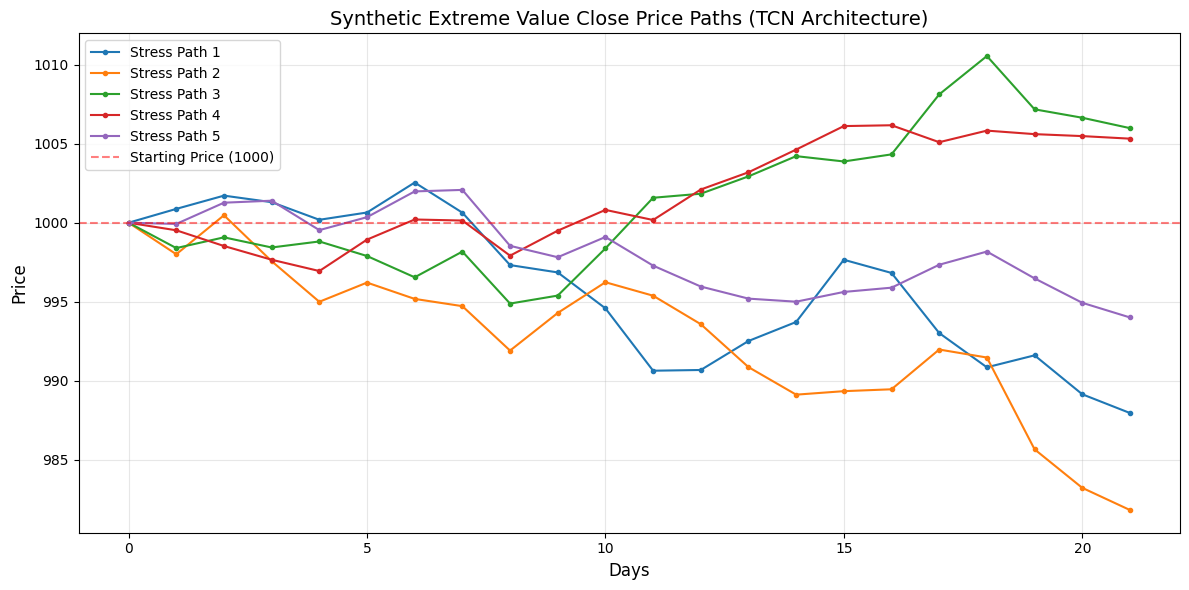

In [29]:
num_paths = 5
base_price = 1000.0
seq_len = 21

with torch.no_grad():
    noise = torch.normal(mean=hist_mean, std=hist_std, size=(num_paths, seq_len, 1)).to(device)
    extreme_returns = rng(noise)
    s_prime = rng_encoder(extreme_returns)
    z_final = generator(s_prime)
    market_outputs = decoder(z_final)

close_log_returns = market_outputs[:, :, 3].cpu().numpy()

price_paths = np.zeros((num_paths, seq_len + 1))
price_paths[:, 0] = base_price

for i in range(1, seq_len + 1):
    price_paths[:, i] = np.exp(close_log_returns[:, i-1]) * price_paths[:, i-1]

plt.figure(figsize=(12, 6))
for i in range(num_paths):
    plt.plot(price_paths[i], marker='o', markersize=3, label=f'Stress Path {i+1}')

plt.title('Synthetic Extreme Value Close Price Paths (TCN Architecture)', fontsize=14)
plt.xlabel('Days', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.axhline(y=base_price, color='r', linestyle='--', alpha=0.5, label='Starting Price (1000)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Continuous Stitching & Macro-Scenario Visualization

To visualize extended macro-stress scenarios beyond the 21-day training window, we dynamically stitch multiple generated sequences together.

**1. Sequence Stitching & Trimming:**
The network generates data in strict 21-day chunks. To create a seamless timeline of any arbitrary length (e.g., 252 days), the pipeline generates the `ceiling` of required chunks, concatenates them along the time dimension, and strictly trims the excess tail to match the exact target length.

**2. Physical Reconstruction & Daily Anchoring:**
Because the neural network predicts the log-returns of Open, High, Low, and Close independently, computing four separate cumulative products over long horizons causes "structural drift" (e.g., candlesticks stretching to impossible heights). To fix this, we establish the `Close` price as the core macro-trend anchor. The intraday metrics (Open, High, Low) are then calculated relative to *yesterday's Close*. Finally, we enforce strict logical gates (`max` and `min`) to guarantee the High is the absolute ceiling and the Low is the absolute floor, ensuring flawless candlestick rendering.

**3. Moving Averages:**
The chart includes standard financial indicators to analyze the synthetic trend:
*   **Close MAs:** 7-day and 21-day moving averages applied to the closing price.
*   **Volume MA:** A custom 7-day moving average plotted over the volume sub-chart.

Generating 6 chunks to reach 126 days...


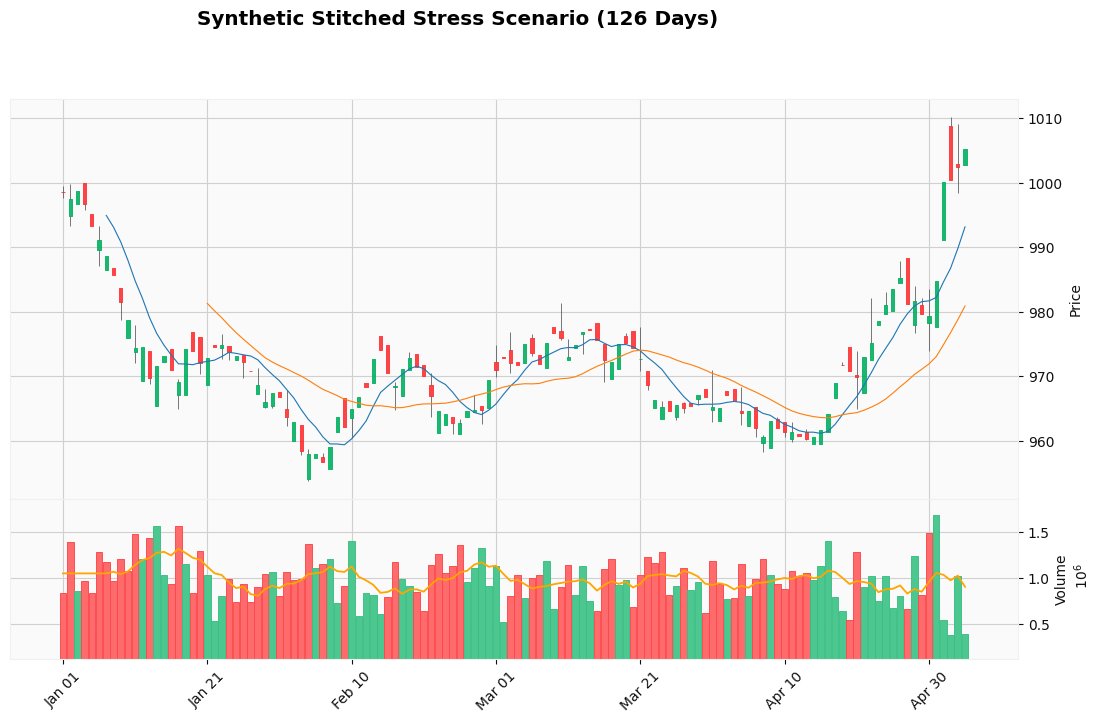

In [35]:
TARGET_DAYS = 126
BASE_PRICE = 1000.0
BASE_VOLUME = 1000000.0
num_chunks = math.ceil(TARGET_DAYS / 21)
chunks_list = []

# Ensure all models are in evaluation mode
generator.eval()
decoder.eval()
rng.eval()
rng_encoder.eval()

print(f"Generating {num_chunks} chunks to reach {TARGET_DAYS} days...")

with torch.no_grad():
    for _ in range(num_chunks):
        # Generate 21 days of noise
        noise = torch.normal(mean=hist_mean, std=hist_std, size=(1, 21, 1)).to(device)

        # Pipeline execution
        extreme_returns = rng(noise)
        s_prime = rng_encoder(extreme_returns)
        z_final = generator(s_prime)
        market_outputs = decoder(z_final) # Shape: (1, 21, 5)

        chunks_list.append(market_outputs)

# Concatenate along the time dimension (dim=1) and trim to exact TARGET_DAYS
stitched_tensor = torch.cat(chunks_list, dim=1)
trimmed_tensor = stitched_tensor[:, :TARGET_DAYS, :]

# Extract the 5 feature arrays for the single stitched path
O_ret = trimmed_tensor[0, :, 0].cpu().numpy()
H_ret = trimmed_tensor[0, :, 1].cpu().numpy()
L_ret = trimmed_tensor[0, :, 2].cpu().numpy()
C_ret = trimmed_tensor[0, :, 3].cpu().numpy()
V_ret = trimmed_tensor[0, :, 4].cpu().numpy()

# Initialize arrays
O, H, L, C, V = (np.zeros(TARGET_DAYS) for _ in range(5))

# Initialize base values for Day 0
O[0] = BASE_PRICE * np.exp(O_ret[0])
H[0] = BASE_PRICE * np.exp(H_ret[0])
L[0] = BASE_PRICE * np.exp(L_ret[0])
C[0] = BASE_PRICE * np.exp(C_ret[0])
V[0] = BASE_VOLUME * abs(np.exp(V_ret[0]) - 1)

# Iterative cumulative reconstruction
for i in range(1, TARGET_DAYS):
    # 1. Calculate the core Close price trend (The Daily Anchor)
    C[i] = C[i-1] * np.exp(C_ret[i])

    # 2. Anchor the intraday movements to yesterday's Close to prevent structural drift
    O[i] = C[i-1] * np.exp(O_ret[i])
    raw_H = C[i-1] * np.exp(H_ret[i])
    raw_L = C[i-1] * np.exp(L_ret[i])

    # 3. ENFORCE CANDLE VALIDITY:
    # High must be the absolute max, Low must be the absolute min of the day
    H[i] = max(raw_H, O[i], C[i])
    L[i] = min(raw_L, O[i], C[i])

    # 4. Reconstruct volume multiplier
    V[i] = BASE_VOLUME * abs(np.exp(V_ret[i]) - 1)
    # Floor volume to prevent rendering zero-volume glitches
    V[i] = max(V[i], 1000)

# mplfinance requires a pandas DataFrame with a DatetimeIndex
dates = pd.date_range(start='2024-01-01', periods=TARGET_DAYS)
df = pd.DataFrame({'Open': O, 'High': H, 'Low': L, 'Close': C, 'Volume': V}, index=dates)

# Calculate Custom Moving Average for Volume (7-day)
df['Vol_MA_7'] = df['Volume'].rolling(window=7).mean().bfill()

# Create the custom AddPlot for the Volume MA (panel 1 is the volume panel)
ap_vol = mpf.make_addplot(df['Vol_MA_7'], panel=1, color='orange', secondary_y=False)

# Render the Candlestick Chart
mpf.plot(
    df,
    type='candle',
    volume=True,
    mav=(7, 21),       # Adds 7-day and 21-day Moving Averages for the Close price
    addplot=ap_vol,    # Attaches our custom Volume MA
    style='yahoo',     # Classic Red/Green financial styling
    title=f"Synthetic Stitched Stress Scenario ({TARGET_DAYS} Days)",
    ylabel="Price",
    ylabel_lower="Volume",
    figsize=(14, 8)
)